# AMR Genome Project

# Sourcing

In [ ]:
# Focus (drop) --> Antimicrobial Resistance for Acinetobacter (Antibiotic: Fluroquinolones)
# Indicator: Resistant Isolates in Percentage
# Places: Europe
# Source: ECDC
print("AMR Genome Project")

AMR Genome Project


# Data Preprocessing

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("AMR.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   HealthTopic  358 non-null    object 
 1   Population   358 non-null    object 
 2   Indicator    358 non-null    object 
 3   Unit         358 non-null    object 
 4   Time         358 non-null    int64  
 5   RegionCode   358 non-null    object 
 6   RegionName   358 non-null    object 
 7   NumValue     358 non-null    object 
 8   TxtValue     0 non-null      float64
dtypes: float64(1), int64(1), object(7)
memory usage: 25.3+ KB


,HealthTopic,Population,Indicator,Unit,Time,RegionCode,RegionName,NumValue,TxtValue
0,Antimicrobial resistance,Acinetobacter spp.|Fluoroquinolones,"R - resistant isolates, percentage",%,2012,AT,Austria,-,NaN
1,Antimicrobial resistance,Acinetobacter spp.|Fluoroquinolones,"R - resistant isolates, percentage",%,2012,BE,Belgium,-,NaN
2,Antimicrobial resistance,Acinetobacter spp.|Fluoroquinolones,"R - resistant isolates, percentage",%,2012,BG,Bulgaria,69.230769230,NaN
3,Antimicrobial resistance,Acinetobacter spp.|Fluoroquinolones,"R - resistant isolates, percentage",%,2012,CY,Cyprus,56.521739130,NaN
4,Antimicrobial resistance,Acinetobacter spp.|Fluoroquinolones,"R - resistant isolates, percentage",%,2012,CZ,Czechia,-,NaN


In [ ]:
df.drop(["HealthTopic", "Population", "RegionCode", "TxtValue", "Unit", "Indicator"], axis=1, inplace=True)
df.tail()

,Time,RegionName,NumValue
353,2023,Portugal,46.153846150
354,2023,Romania,87.724550890
355,2023,Sweden,2.564102560
356,2023,Slovenia,25.000000000
357,2023,Slovakia,48.684210520


# Data Encoding/ Normalization

In [ ]:
# Time encoding --> remove later if not necessary. One hot encoding?
# No sine and cos because not cyclical

# Look back at data Normalization ipynb and apply one later
label_mapping = {2011:0, 2012:1, 2013:2, 2014:3, 2015:4, 2016:5, 2017:6, 2018:7, 2019:8, 2020:9, 2021:10, 2022:11, 2023: 12, 2024:13, 2025: 14}
# Introducing purposeful bias
df.replace(label_mapping, inplace=True)
df = df.rename(columns={'Time': 'Year', 'RegionName': 'Region', 'NumValue': 'Percentage'})

In [ ]:
# Finding uniques on Map
print(df["Region"].unique())

['Austria' 'Belgium' 'Bulgaria' 'Cyprus' 'Czechia' 'Germany' 'Denmark'
 'Estonia' 'Greece' 'Spain' 'Finland' 'France' 'Croatia' 'Hungary'
 'Ireland' 'Iceland' 'Italy' 'Lithuania' 'Luxembourg' 'Latvia' 'Malta'
 'Netherlands' 'Norway' 'Poland' 'Portugal' 'Romania' 'Sweden' 'Slovenia'
 'Slovakia' 'United Kingdom' 'Liechtenstein']


In [ ]:
# Dropping nuisances smh
import numpy as np
df['Percentage'] = df['Percentage'].replace('-', np.nan)
df.dropna(inplace=True)
print(df.isnull().sum())
df = df.reset_index(drop=True)

# Normalization
df["Percentage"] = df["Percentage"].astype(float)
df["Percentage"] = df["Percentage"] * 0.01

Year          0
Region        0
Percentage    0
dtype: int64


In [ ]:
# One hot

# Embedding mapping using Word2Vec
model: google-news-300

In [ ]:
!pip install gensim
import numpy as np
!pip install --upgrade --force-reinstall numpy gensim # package compatibility issues

import gensim.downloader as api

# Load pretrained
model = api.load('word2vec-google-news-300')


# list of countries
countries = ['Bulgaria', 'Cyprus', 'Germany', 'Denmark', 'Greece', 'France', 'Hungary',
             'Italy', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovenia',
             'United Kingdom', 'Austria', 'Czechia', 'Spain', 'Finland', 'Croatia',
             'Ireland', 'Sweden', 'Slovakia', 'Lithuania', 'Latvia', 'Belgium', 'Malta']


country_embeddings = {}
for country in countries:
    if country in model:  # Check if the country is in the vocabulary
        country_embeddings[country] = model[country]
    else:
        print(f"Country '{country}' not found in the model's vocabulary.")

# dictionary created

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp311-cp

In [ ]:
# Sadly, UK gotta go lol unless i can embed that

df = df[df['Region'] != 'United Kingdom']
df['Region'].unique()

array(['Bulgaria', 'Cyprus', 'Germany', 'Denmark', 'Greece', 'France',
       'Hungary', 'Italy', 'Netherlands', 'Norway', 'Poland', 'Portugal',
       'Romania', 'Slovenia', 'Austria', 'Czechia', 'Spain', 'Finland',
       'Croatia', 'Ireland', 'Sweden', 'Slovakia', 'Lithuania', 'Latvia',
       'Belgium', 'Malta'], dtype=object)

In [ ]:
# Check dictionary and map!
country_embeddings['Bulgaria']
df['Country_Embedding'] = df['Region'].map(country_embeddings)

<ipython-input-10-c915488c1702>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Country_Embedding'] = df['Region'].map(country_embeddings)


In [ ]:
df.head()
# Embeddings using Word2Vec might reveal hidden correlations, but lets just use a corr map

,Year,Region,Percentage,Country_Embedding
0,1,Bulgaria,0.692308,"[0.23046875, -0.012268066, 0.04272461, 0.09814..."
1,1,Cyprus,0.565217,"[0.35351562, -0.032470703, -0.18847656, -0.019..."
2,1,Germany,0.082645,"[0.25976562, 0.140625, 0.24707031, 0.009582519..."
3,1,Denmark,0.120482,"[0.08300781, -0.16113281, 0.07470703, -0.00199..."
4,1,Greece,0.931063,"[0.47265625, 0.007019043, 0.05908203, 0.090332..."


# 2D Correlational Matrix

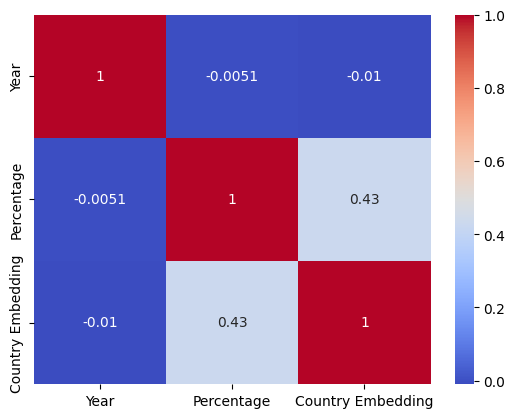

In [ ]:
dfs = df[["Year", "Percentage", "Country_Embedding"]].copy()
dfs['Country_Embedding_Numerical'] = dfs['Country_Embedding'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)


data_array = dfs[["Year", "Percentage", "Country_Embedding_Numerical"]].to_numpy()


correlation_matrix = np.corrcoef(data_array, rowvar=False)

#heatmap in alternate of this: dfs[["Year", "Percentage", "Country_Embedding_Numerical"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",
            xticklabels=["Year", "Percentage", "Country Embedding"],
            yticklabels=["Year", "Percentage", "Country Embedding"])
plt.show()




# ???? what the heck

# 3D Linear Regression Model

In [ ]:
import numpy as np
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

# Option 1: Was going to oversample but its not discrete


# Option 2: SMOTE but sadly i don't want to threshold

'''
from imblearn.over_sampling import SMOTE

X = dfs[['Year', 'Country_Embedding_Numerical']]  # Assuming you have 'Country_Embedding_Numerical'
y = dfs['Percentage']

#  'Percentage' is continuous,  need to convert it into categories for SMOTE
# threshold = 0.5
# y = (df['Percentage'] > threshold).astype(int)
# Sucks to suck ig


smote = SMOTE(random_state=42)  # You can change the random_state
X_resampled, y_resampled = smote.fit_resample(X, y)


df_resampled = pd.DataFrame(X_resampled, columns=['Year', 'Country_Embedding_Numerical'])
df_resampled['Percentage'] = y_resampled

'''

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


"\nfrom imblearn.over_sampling import SMOTE\n\nX = dfs[['Year', 'Country_Embedding_Numerical']]  # Assuming you have 'Country_Embedding_Numerical'\ny = dfs['Percentage']\n\n#  'Percentage' is continuous,  need to convert it into categories for SMOTE\n# threshold = 0.5\n# y = (df['Percentage'] > threshold).astype(int)\n# Sucks to suck ig\n\n\nsmote = SMOTE(random_state=42)  # You can change the random_state\nX_resampled, y_resampled = smote.fit_resample(X, y)\n\n\ndf_resampled = pd.DataFrame(X_resampled, columns=['Year', 'Country_Embedding_Numerical'])\ndf_resampled['Percentage'] = y_resampled\n\n"

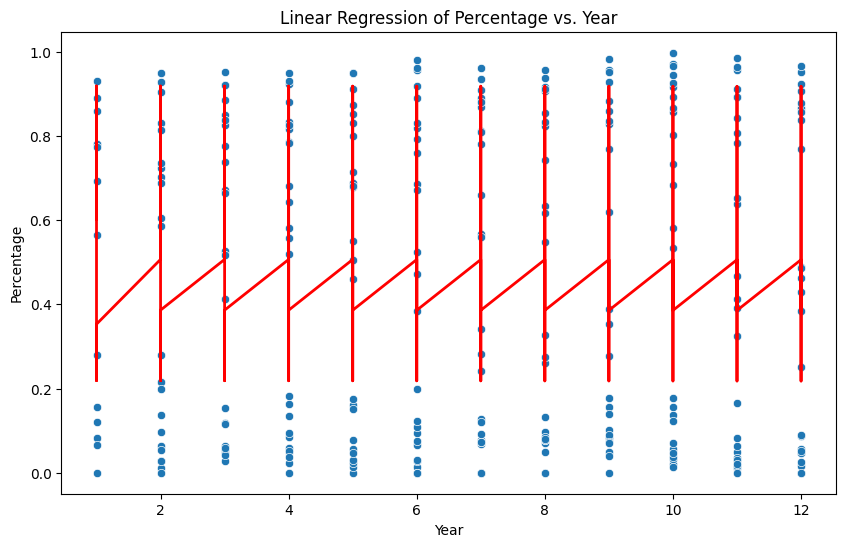

In [ ]:
from sklearn import linear_model

ig = linear_model.LinearRegression()
ig.fit(dfs[["Year", "Country_Embedding_Numerical"]], dfs["Percentage"])

predictions = ig.predict(dfs[["Year", "Country_Embedding_Numerical"]])

# Create a scatter plot of the data
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
sns.scatterplot(x="Year", y="Percentage", data=dfs)

# Plot the regression line
plt.plot(dfs["Year"], predictions, color='red', linewidth=2)

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.title("Linear Regression of Percentage vs. Year")

plt.show()


# Amazing trash because of 3D (places matter too sob sob)

# Support Vector Regression (SVR)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


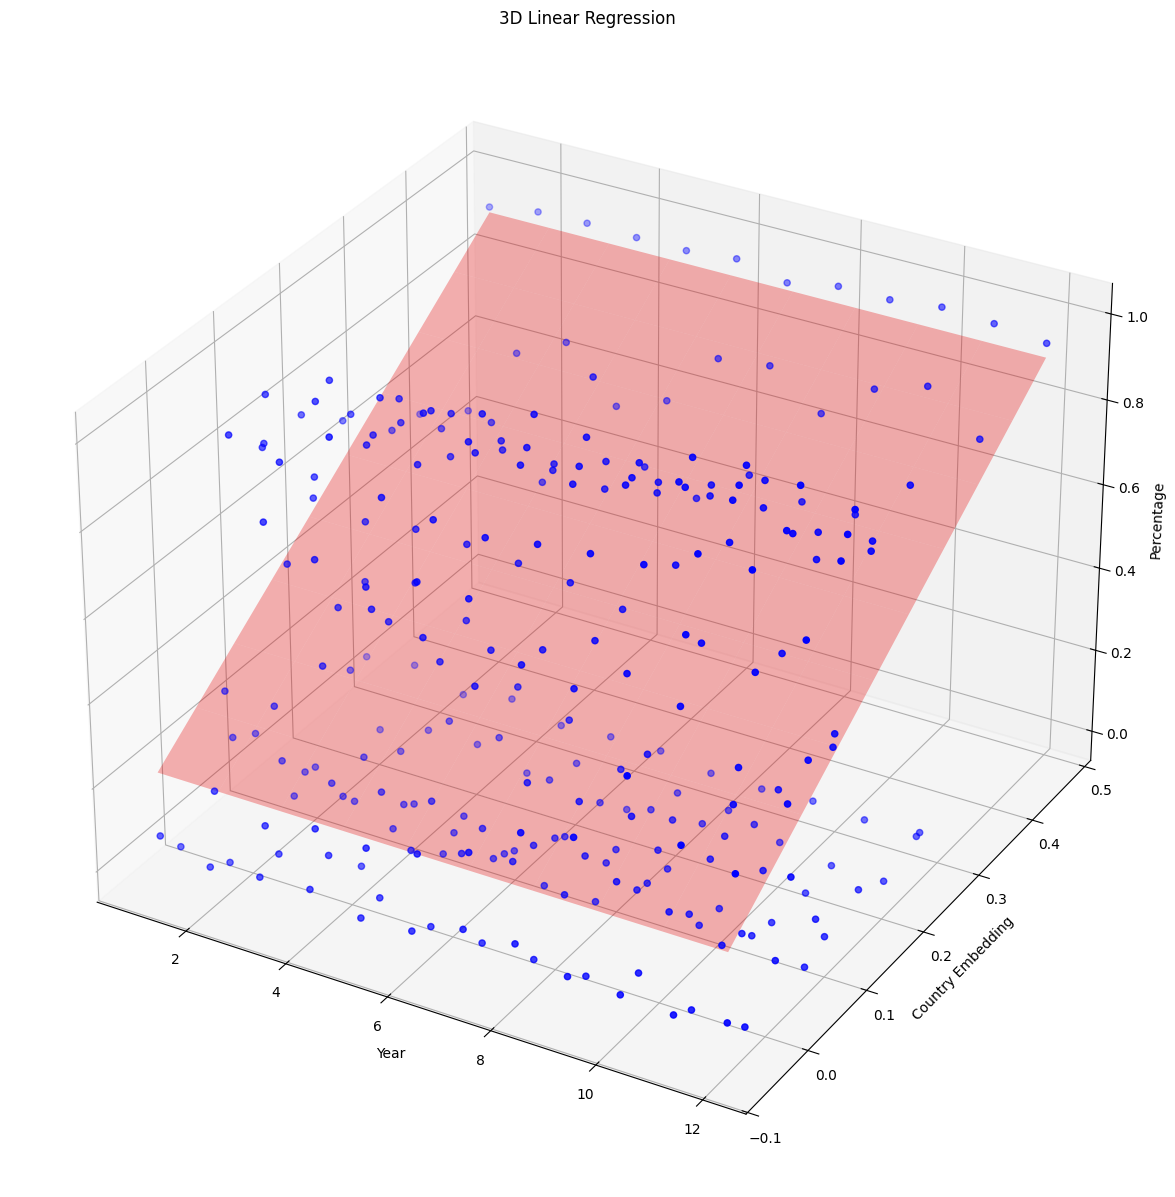

In [ ]:
import numpy as np
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D




ig = linear_model.LinearRegression()
# Model built
ig.fit(dfs[["Year", "Country_Embedding_Numerical"]], dfs["Percentage"])

# Predict again
predictions = ig.predict(dfs[["Year", "Country_Embedding_Numerical"]])


fig = plt.figure(figsize=(20, 15))
# axes 3d
ax = fig.add_subplot(111, projection='3d')

ax.scatter(dfs["Year"], dfs["Country_Embedding_Numerical"], dfs["Percentage"], c='blue', marker='o')

#meshgrid
x_surface, y_surface = np.meshgrid(np.linspace(dfs["Year"].min(), dfs["Year"].max(), 10),
                             np.linspace(dfs["Country_Embedding_Numerical"].min(), dfs["Country_Embedding_Numerical"].max(), 10))

z_surface = ig.predict(np.array([x_surface.ravel(), y_surface.ravel()]).T).reshape(x_surface.shape)


ax.plot_surface(x_surface, y_surface, z_surface, color='red', alpha=0.3)

ax.set_xlabel("Year")
ax.set_ylabel("Country Embedding")
ax.set_zlabel("Percentage")
ax.set_title("3D Linear Regression")

plt.show()

In [ ]:
# Horribly enough, its proven that linear relationship between country and datapoints, but year, not really. That's really bad for this mission statement.
#Asking the computer to predict and send a report!
#import sklearn.metrics
# print(sklearn.metrics.classification_report(dfs["Percentage"], predictions))

# AHHHHH I HATE CONTINUOUS DATA SO MUCH
from sklearn.metrics import mean_squared_error, r2_score

#Calculate Mean Squared Error (MSE)
mse = mean_squared_error(dfs["Percentage"], predictions)

#Calculate R-squared (R^2)
r2 = r2_score(dfs["Percentage"], predictions)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")


# OMG linear regression did NOT work at all

Mean Squared Error (MSE): 0.1092925296174597
R-squared (R^2): 0.18550742444994284


Mean Squared Error (MSE): 0.12187342890750795
R-squared (R^2): 0.09174942377639728


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


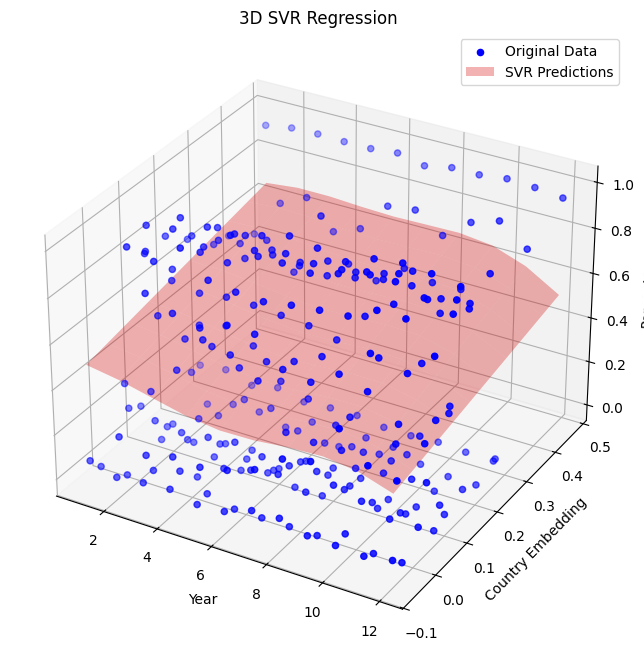

In [ ]:
# Might need to encode year further? idk atp might be an issue with missing years in between some
# i give up, lets tryyy an SVM


# Nevermind, SVR

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

svm_model = SVR()

svm_model = svm_model.fit(dfs[["Year", "Country_Embedding_Numerical"]], dfs["Percentage"])
predictions = svm_model.predict(dfs[["Year", "Country_Embedding_Numerical"]])
mse = mean_squared_error(dfs["Percentage"], predictions)

r2 = r2_score(dfs["Percentage"], predictions)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")

# imagine working even less



fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(dfs["Year"], dfs["Country_Embedding_Numerical"], dfs["Percentage"],
           c='blue', marker='o', label='Original Data')


x_surf, y_surf = np.meshgrid(np.linspace(dfs["Year"].min(), dfs["Year"].max(), 10),
                             np.linspace(dfs["Country_Embedding_Numerical"].min(),
                                         dfs["Country_Embedding_Numerical"].max(), 10))


z_surf = svm_model.predict(np.array([x_surf.ravel(), y_surf.ravel()]).T).reshape(x_surf.shape)


ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3, label='SVR Predictions')


ax.set_xlabel("Year")
ax.set_ylabel("Country Embedding")
ax.set_zlabel("Percentage")
ax.set_title("3D SVR Regression")
ax.legend()


plt.show()

# Decision Tree Model using GridSearchCV

##Keep in mind, we are only using the first value

In [ ]:
x = dfs[["Year", "Country_Embedding_Numerical"]]
y = dfs["Percentage"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
# Create Decision Tree classifer object
clf = DecisionTreeRegressor(max_depth = 10) #This makes the depth of the tree

# Train Decision Tree Classifer
clf = clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")

Mean Squared Error (MSE): 0.004414204972960766
R-squared (R^2): 0.9679086092429517


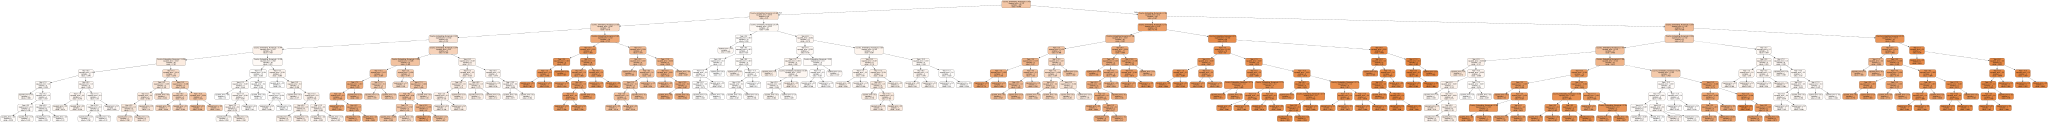

In [ ]:
!pip install graphviz
classes = y.unique()
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names = x.columns,class_names=['0','1'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

Using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Define the hyperparameters and their possible values
param_grid = {
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a decision tree regressor
tree = DecisionTreeRegressor()

# Create GridSearchCV object
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error') # cv is the number of folds in cross-validation

# Fit the grid search to the data
grid_search.fit(x_train, y_train)

# Get the best hyperparameters
print("Best hyperparameters:", grid_search.best_params_)

# Get the best model
best_tree = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred = best_tree.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R^2): {r2}")


Best hyperparameters: {'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mean Squared Error (MSE): 0.00467821933770932
R-squared (R^2): 0.9659892175979061


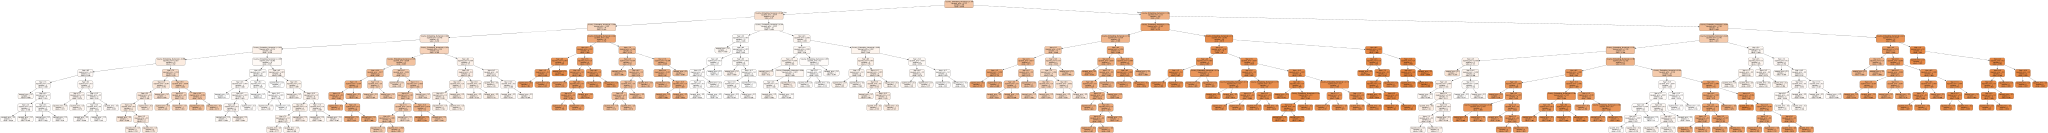

In [ ]:
classes = y.unique()
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(best_tree, out_file=None,
                     feature_names = x.columns,class_names=['0','1'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
# Sample predict using this model

country_name = 'Bulgaria'
year = 50


country_embedding_numerical = country_embeddings[country_name][0]


input_data = pd.DataFrame([[year, country_embedding_numerical]], columns=['Year', 'Country_Embedding_Numerical'])


predicted_percentage = best_tree.predict(input_data)[0]

print(f"Predicted Percentage for {country_name} in {year}: {predicted_percentage}")

# Issues found. Decision tree is limiting increases past a certain point, i.e. Overfitting! (pain)

Predicted Percentage for Bulgaria in 50: 0.80404665895


# Keras Neural Network using Array Embeddings

In [ ]:
!pip install tensorflow
!pip install keras
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization

In [ ]:

'''
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization
import numpy as np  # Import numpy

# Defining keras model architecture
model = Sequential([
    Dense(512, activation='relu', input_shape=(2,), kernel_regularizer=regularizers.l2(0.1)),  # Input shape adjusted
    Dropout(0.5),  # Dropout layer with 50% dropout rate
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, "linear")  # Output layer adjusted for regression
])


x = dfs[["Year", "Country_Embedding"]]  # Use the numerical embedding column
y = dfs["Percentage"]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from keras.optimizers import SGD
import tensorflow as tf
from tensorflow.keras import backend as K

def tolerance_metric(tolerance):
    def metric(y_true, y_pred):
        errors = K.abs(y_true - y_pred)
        return K.mean(K.cast(errors <= tolerance, dtype='float32'))
    return metric

# Define your tolerance
tolerance = 0.1


model.compile(optimizer="adam", loss='mse', metrics=[tolerance_metric(tolerance)])

model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2)
'''

'\nimport tensorflow as tf\nimport keras\nfrom keras import layers\nfrom keras.models import Sequential\nfrom keras.layers import Dense, Dropout\nfrom keras.optimizers import Adam\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras import regularizers\nfrom tensorflow.keras.layers import BatchNormalization\nimport numpy as np  # Import numpy\n\n# Defining keras model architecture\nmodel = Sequential([\n    Dense(512, activation=\'relu\', input_shape=(2,), kernel_regularizer=regularizers.l2(0.1)),  # Input shape adjusted\n    Dropout(0.5),  # Dropout layer with 50% dropout rate\n    Dense(256, activation=\'relu\'),\n    Dropout(0.5),\n    Dense(128, activation=\'relu\'),\n    Dense(1, "linear")  # Output layer adjusted for regression\n])\n\n\nx = dfs[["Year", "Country_Embedding"]]  # Use the numerical embedding column\ny = dfs["Percentage"]\n\nfrom sklearn.model_selection import train_test_split\nx_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,

In [ ]:
# First pass
'''
loss, tolerance_metric_value = model.evaluate(x_test, y_test, verbose=0)
print(f"Mean Squared Error (MSE): {loss}")
print(f"Tolerance Metric: {tolerance_metric_value}")
'''

'\nloss, tolerance_metric_value = model.evaluate(x_test, y_test, verbose=0)\nprint(f"Mean Squared Error (MSE): {loss}")\nprint(f"Tolerance Metric: {tolerance_metric_value}")\n'

Time to flatten embeddings for more data

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 209ms/step - loss: 36.4353 - metric: 0.1574 - mse: 0.2937 - val_loss: 30.8020 - val_metric: 0.1295 - val_mse: 0.1686
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 29.3720 - metric: 0.1304 - mse: 0.2362 - val_loss: 24.5467 - val_metric: 0.2009 - val_mse: 0.1149
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 23.3660 - metric: 0.1699 - mse: 0.1950 - val_loss: 19.3467 - val_metric: 0.1451 - val_mse: 0.1072
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 18.3426 - metric: 0.1616 - mse: 0.1422 - val_loss: 15.0509 - val_metric: 0.2165 - val_mse: 0.0716
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 14.2462 - metric: 0.1955 - mse: 0.1090 - val_loss: 11.6132 - val_metric: 0.2790 - val_mse: 0.0745
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 10.9849 - metric: 0.2207 - mse: 0.1192 - val_loss: 8.8649 - val_metric: 0.3304 - val_mse: 0.0642
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 8.3588

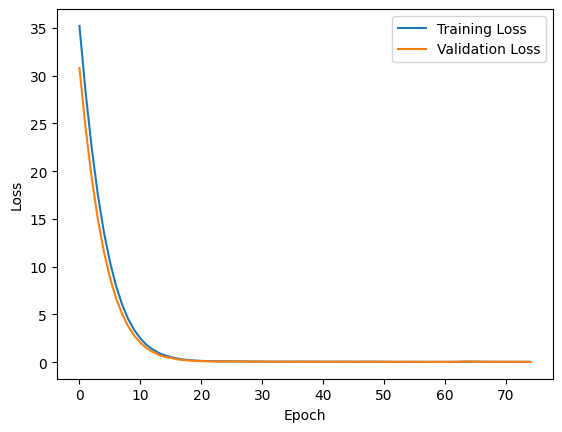

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization
import numpy as np
import matplotlib.pyplot as plt
#from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
#from keras.optimizers import SGD
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping


# Define
def tolerance_metric(tolerance):
    def metric(y_true, y_pred):
        errors = K.abs(y_true - y_pred)
        return K.mean(K.cast(errors <= tolerance, dtype='float32'))
    return metric


model = Sequential([
    Flatten(input_shape=(301,)),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.1)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, "linear")
])

# Prepare
x = dfs[["Year", "Country_Embedding"]]
y = dfs["Percentage"]

x_values = []
for index, row in x.iterrows():
    embedding = row['Country_Embedding']
    year = [row['Year']]
    combined = np.concatenate([year, embedding])
    x_values.append(combined)

x = np.array(x_values)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


tolerance = 0.1

model.compile(optimizer="adam", loss='mse', metrics=[tolerance_metric(tolerance), 'mse'])


early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)


history = model.fit(x_train, y_train, epochs=250,
                    batch_size=32, validation_split=0.2,
                    callbacks=[early_stopping]) # early stopping


loss, tolerance_metric_value, mse = model.evaluate(x_test, y_test, verbose=0) # updated
print(f"Mean Squared Error (MSE): {loss}")
print(f"Tolerance Metric: {tolerance_metric_value}")
print(f"MSE: {mse}") # print standard

#plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True) (Already done)


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predictions & Export Module

In [ ]:
import numpy as np

def predict_percentage(country_name, year):
    country_embedding = country_embeddings[country_name]


    input_data = np.concatenate([[year], country_embedding])
    input_data = input_data.reshape(1, -1)

    predicted_percentage = model.predict(input_data)[0][0]

    return predicted_percentage

# Test
country_name = 'Austria'
year = 2015

predicted_percentage = predict_percentage(country_name, year - 2011)
print(f"Predicted Percentage for {country_name} in {year}: {predicted_percentage}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Predicted Percentage for Austria in 2015: 0.08566055446863174


In [ ]:
i = 0
for country in df["Region"].unique():
    i += 1

    print(country + ": " + str(i))

Bulgaria: 1
Cyprus: 2
Germany: 3
Denmark: 4
Greece: 5
France: 6
Hungary: 7
Italy: 8
Netherlands: 9
Norway: 10
Poland: 11
Portugal: 12
Romania: 13
Slovenia: 14
Austria: 15
Czechia: 16
Spain: 17
Finland: 18
Croatia: 19
Ireland: 20
Sweden: 21
Slovakia: 22
Lithuania: 23
Latvia: 24
Belgium: 25
Malta: 26


In [ ]:
all_predictions = []


for country in df["Region"].unique():
    for year in range(0, 76):  # Years 0-75
        predicted_value = predict_percentage(country, year)
        all_predictions.append([country, year, predicted_value])

predictions_df = pd.DataFrame(all_predictions, columns=["Country", "Year", "Predicted Percentage"])


print(predictions_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/st

In [ ]:

predictions_df

,Country,Year,Predicted Percentage
0,Bulgaria,0,0.812721
1,Bulgaria,1,0.812183
2,Bulgaria,2,0.812306
3,Bulgaria,3,0.817120
4,Bulgaria,4,0.825857
...,...,...,...
1971,Malta,71,0.583370
1972,Malta,72,0.584072
1973,Malta,73,0.584783
1974,Malta,74,0.585493


In [ ]:
# Iteration 3, Limiting probabilities to 1
'''
predictions_df['Predicted Percentage'] = predictions_df['Predicted Percentage'].clip(upper=1)
predictions_df
'''

"\npredictions_df['Predicted Percentage'] = predictions_df['Predicted Percentage'].clip(upper=1)\npredictions_df\n"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Folder create

if not os.path.exists("country_predictions"):
    os.makedirs("country_predictions")

for country in predictions_df['Country'].unique():
    country_data = predictions_df[predictions_df['Country'] == country]
    plt.figure(figsize=(10, 6))
    sns.lineplot(x='Year', y='Predicted Percentage', data=country_data)
    plt.title(f'Year vs. Predicted Percentage for {country}')
    plt.xlabel('Year')
    plt.ylabel('Predicted Percentage')
    plt.grid(True)


    file_path = os.path.join("country_predictions", f'{country}_prediction.png')
    plt.savefig(file_path)
    plt.show()

    predictions_df.to_csv('predictions.csv', index=False)

In [ ]:
!zip -r /content/3-Pred.zip /content/3\ -\ Pred\ \(Early\ Stopping-Adam-250-Upperclip1\)
from google.colab import files
files.download('/content/3-Pred.zip')

# Cartographic Visualization Pre-Process

In [ ]:
predictions_df

In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
import time

# Your dataset (predictions_df)

# Initialize geolocator
geolocator = Nominatim(user_agent="geoapiExercises")

# Function to get geocodes with retry
def get_geocode_with_retry(country, max_retries=3, retry_delay=5):
    for i in range(max_retries):
        try:
            location = geolocator.geocode(country)
            return (location.latitude, location.longitude)
        except Exception as e:
            print(f"Error geocoding {country}: {e}")
            if i < max_retries - 1:
                print(f"Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
            else:
                print(f"Max retries reached for {country}. Returning None.")
                return (None, None)

# Apply geocode function with retry and create new column
predictions_df['Geocodes'] = predictions_df['Country'].apply(get_geocode_with_retry)

# Adjust the 'Year' column
predictions_df['Year'] = predictions_df['Year'] + 2011

# Display the modified DataFrame
print(predictions_df)